# Exploratory Data Analysis (EDA)

This notebook performs comprehensive EDA on the HCMC Air Quality dataset for the target variable PM2.5 and meteorological features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from windrose import WindroseAxes
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data
Loading the preprocessed dataset `data/processed/hcmc_merged_cleaned.csv` and setting the datetime index.

In [2]:
# Load data
df = pd.read_csv('../data/processed/hcmc_merged_cleaned.csv')
df = df.iloc[:int(len(df)*0.6)] # Sliced to top 60% for EDA without data leakage
print(f"Sliced EDA Data Shape: {df.shape}")

# Convert datetime_local to datetime and set as index
if 'datetime_local' in df.columns:
    df['datetime_local'] = pd.to_datetime(df['datetime_local'])
    df = df.set_index('datetime_local')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10735, 12)


,pm1,pm25,relativehumidity,temperature,um003,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,boundary_layer_height
datetime_local,,,,,,,,,,,,
2024-11-19 18:00:00+07:00,18.600000,29.139999,62.800000,27.172000,3519.660059,30.9,59.0,0.1,1007.6,1.0,211.0,150.0
2024-11-19 19:00:00+07:00,18.700000,29.150000,57.816667,29.025001,3363.499980,29.3,68.0,0.0,1008.4,4.9,204.0,245.0
2024-11-19 20:00:00+07:00,20.533333,31.783333,57.333333,29.130000,3903.650004,26.6,77.0,0.2,1009.5,2.8,105.0,95.0
2024-11-19 21:00:00+07:00,20.016667,30.950000,56.883334,29.161667,3583.299988,26.6,79.0,0.1,1010.0,4.0,309.0,85.0
2024-11-19 22:00:00+07:00,19.679167,30.216667,56.395833,29.043750,3495.024984,26.8,79.0,0.0,1009.9,3.2,164.0,55.0


In [3]:
def plot_distribution(column_name, title, bins=50, unit=''):
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
    
    sns.boxplot(x=df[column_name], ax=ax_box, color='skyblue')
    sns.histplot(data=df, x=column_name, ax=ax_hist, bins=bins, kde=True, color='skyblue')
    
    ax_box.set(xlabel='')
    ax_box.set_title(title, fontweight='bold', fontsize=14)
    ax_hist.set_xlabel(f"{column_name} {unit}")
    ax_hist.set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

## 2. Univariate Analysis
Analyzing the distribution and identifying potential outliers for each individual variable.

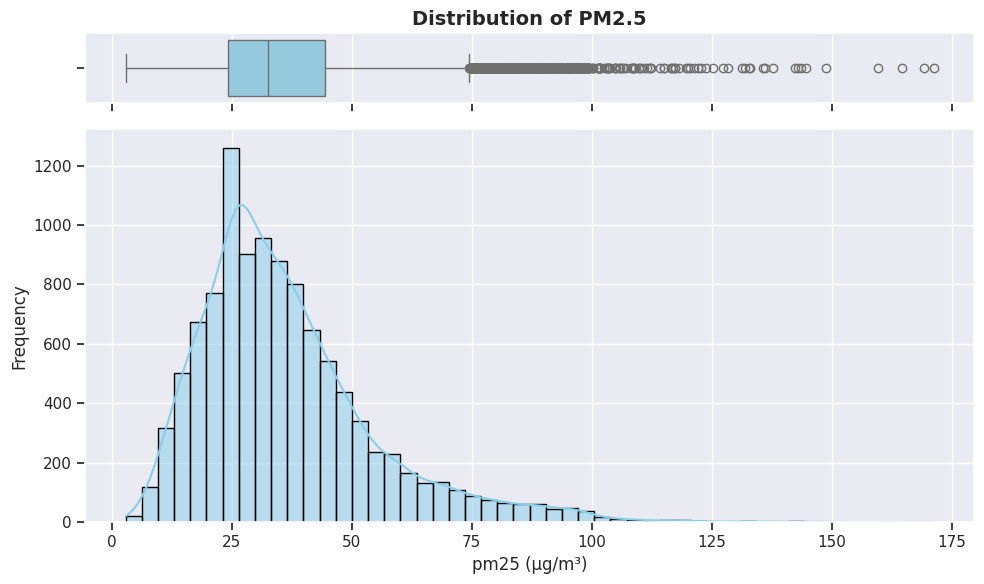

In [4]:
plot_distribution('pm25', 'Distribution of PM2.5', unit='(µg/m³)')

> **Insight - PM2.5**:
> - Phân phối của PM2.5 bị lệch phải rất mạnh (Right-skewed). Đỉnh của phân phối (Mode) tập trung ở dải giá trị thấp (25 µg/m3).
> - Không được xóa (drop) các outliers này: Đây không phải là lỗi đo đạc (sensor error) mà phản ánh các sự kiện ô nhiễm cực đoan thực tế (ví dụ: giờ cao điểm kẹt xe, hiện tượng nghịch nhiệt).
> - Đối với các mô hình nhạy cảm với phương sai và phân phối như ARIMA hay LSTM/GRU, bạn nên áp dụng phép biến đổi Logarit (Log Transformation - ví dụ np.log1p) hoặc Box-Cox để đưa phân phối về dạng gần chuẩn (Normal distribution) hơn.

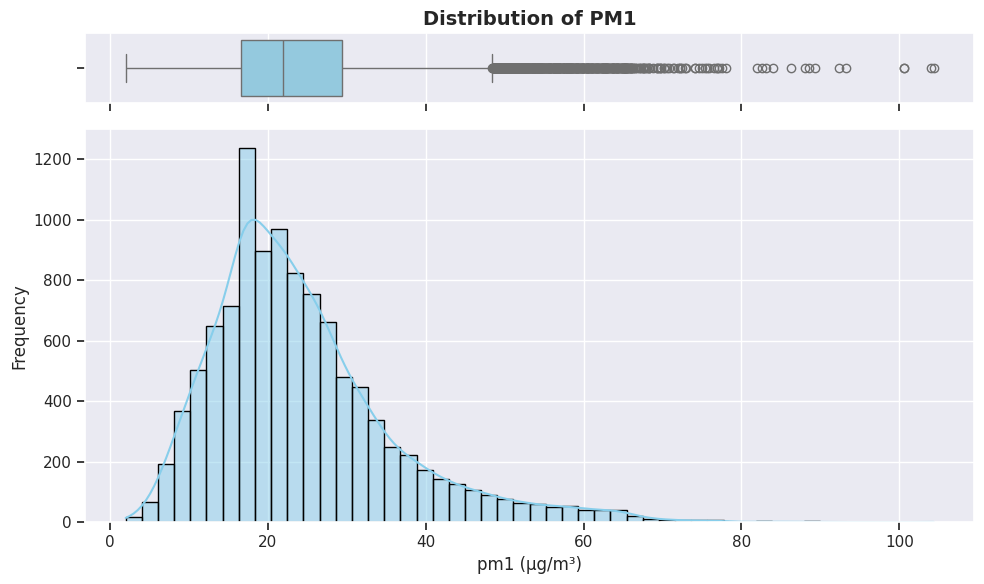

In [5]:
plot_distribution('pm1', 'Distribution of PM1', unit='(µg/m³)')

> **Insight - PM1**:
> - Hạt PM1 nhỏ hơn và nguy hiểm hơn. Nồng độ PM1 thường có sự tương quan tuyến tính rất chặt chẽ theo PM2.5.
> - Phân phối của PM1 lệch phải rất mạnh (Right-skewed). Đỉnh (Mode) tập trung ở dải giá trị thấp (dưới 20 µg/m³).
> - Lưu ý vì PM1 tương đồng cao với PM2.5 (có thể loại bỏ)

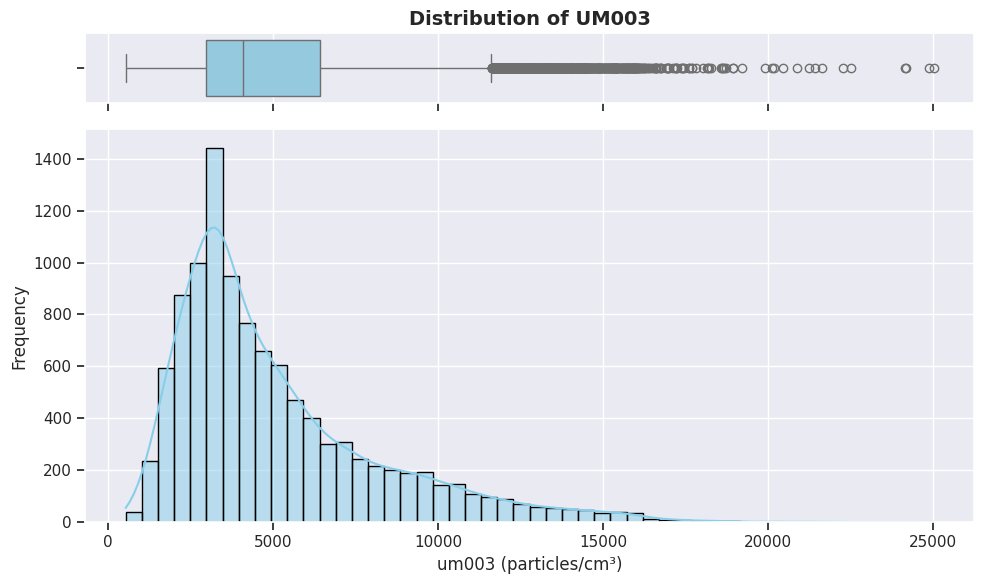

In [6]:
plot_distribution('um003', 'Distribution of UM003', unit='(particles/cm³)')

> **Insight - UM003**:
> - Thể hiện số lượng hạt PM siêu nhỏ trong không khí. Phân phối lệch phải.
> - Không loại bỏ Outliers. Các giá trị chục ngàn này chính là những thời điểm ô nhiễm khói bụi nghiêm trọng nhất tại TP.HCM.
> - Trục x của biến này trải dài từ 0 đến 14000 --> dùng Log Transformation (np.log1p) để đưa phân phối về dạng hình chuông, sau đó có thể ép về khoảng [0, 1] bằng MinMaxScaler.

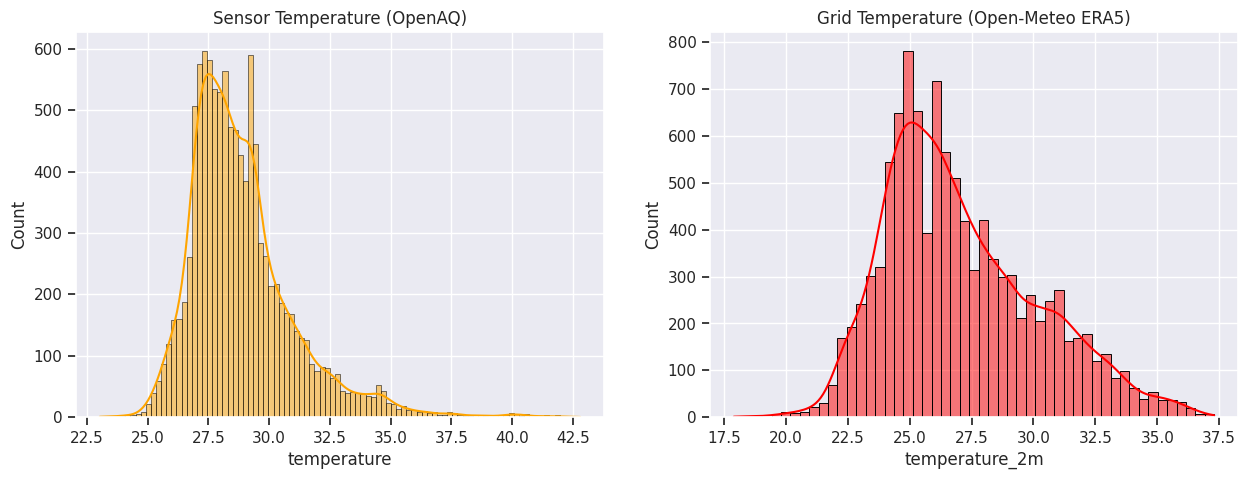

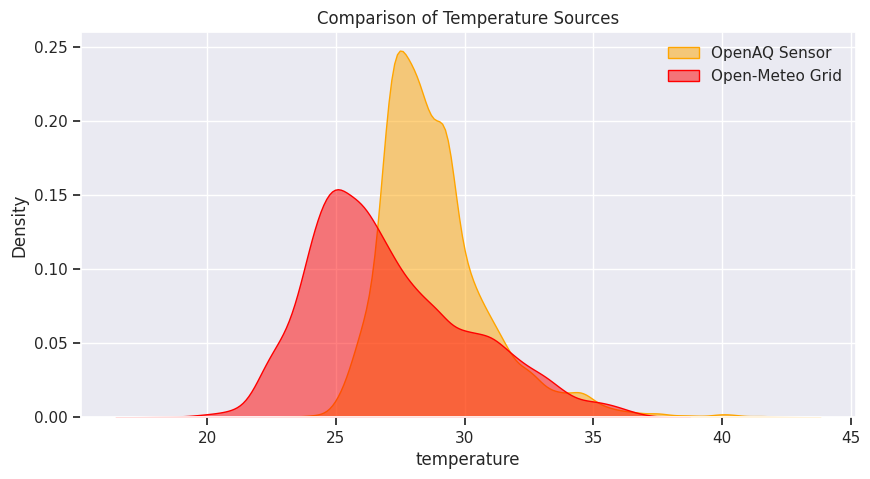

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['temperature'], ax=axes[0], kde=True, color='orange')
axes[0].set_title('Sensor Temperature (OpenAQ)')
sns.histplot(df['temperature_2m'], ax=axes[1], kde=True, color='red')
axes[1].set_title('Grid Temperature (Open-Meteo ERA5)')
plt.show()

# Overlay
plt.figure(figsize=(10, 5))
sns.kdeplot(df['temperature'], label='OpenAQ Sensor', fill=True, color='orange', alpha=0.5)
sns.kdeplot(df['temperature_2m'], label='Open-Meteo Grid', fill=True, color='red', alpha=0.5)
plt.title('Comparison of Temperature Sources')
plt.legend()
plt.show()

> **Insight - Temperature**:
> - `temperature` từ OpenAQ là dữ liệu vi khí hậu (Micro-climate), đo trực tiếp tại vị trí đặt cảm biến --> chứa nhiều noise hơn.
> - `temperature_2m` từ Open-Meteo là dữ liệu khí tượng chuẩn (Synoptic/Macro-climate), thường được nội suy từ các mô hình thời tiết toàn cầu hoặc khu vực, đại diện cho nhiệt độ không khí xung quanh ở độ cao 2 mét so với mặt đất trên một ô lưới (grid cell) rộng. --> ít bị nhiễu và phản ánh đúng xu hướng thời tiết chung của toàn TP.HCM.
> - Preprocessing có những phương án sau:
> > 1. Loại 'temperature' của OpenAQ -> giải pháp an toàn.
> > 2. Feature Engineer để tận dụng 2 biến.

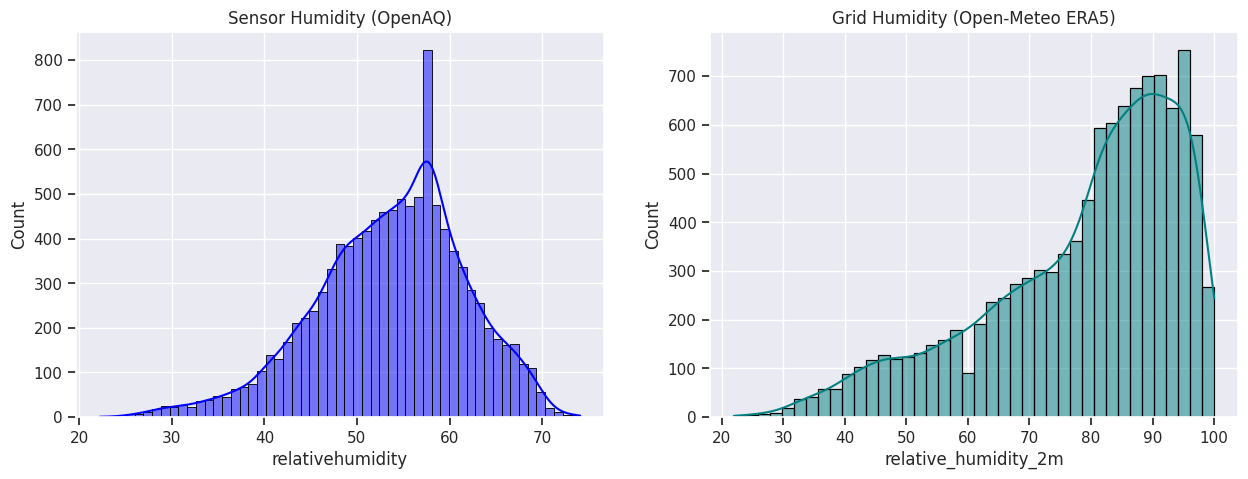

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['relativehumidity'], ax=axes[0], kde=True, color='blue')
axes[0].set_title('Sensor Humidity (OpenAQ)')
sns.histplot(df['relative_humidity_2m'], ax=axes[1], kde=True, color='teal')
axes[1].set_title('Grid Humidity (Open-Meteo ERA5)')
plt.show()

> **Insight - Relative Humidity**:
> - Trong điều kiện ở TP.HCM (khí hậu nhiệt đới gió mùa), độ ẩm thường duy trì ở mức cao (thường từ 60-90%).
> - Loại biến của OpenAQ.

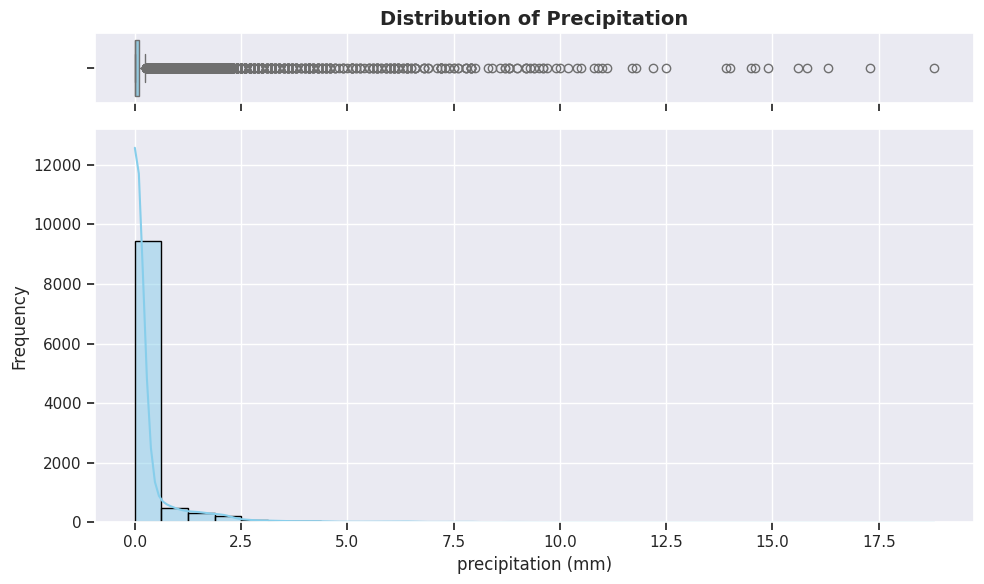

In [9]:
plot_distribution('precipitation', 'Distribution of Precipitation', unit='(mm)', bins=30)

> **Insight - Precipitation**:
> - Phân phối tụt sâu chênh lệch (Zero-Inflated) vì phần lớn số ngày trong năm (đặc biệt trong mùa khô) lượng mưa bằng 0.
> - Giữ nguyên Outliers: Tuyệt đối không xóa các điểm > 0, vì đó chính là những cơn mưa thực sự giúp làm sạch không khí.
> - Không nên Log Transform
> - Do lệch rất nặng, khi Feature Engineering có thể tạo một cờ `is_raining` (0/1) để nắm bắt hiệu ứng "Washing effect" (mưa rửa trôi làm giảm PM2.5 cục bộ).
> - Biến thời gian (Temporal Feature) `hours_since_last_rain` (Số giờ kể từ cơn mưa cuối cùng). Mưa xong thì không khí sạch, nhưng sau đó bụi sẽ tích tụ dần. Biến này sẽ giúp mô hình theo dõi được quá trình "tái ô nhiễm" của không khí TP.HCM sau mỗi đợt mưa.

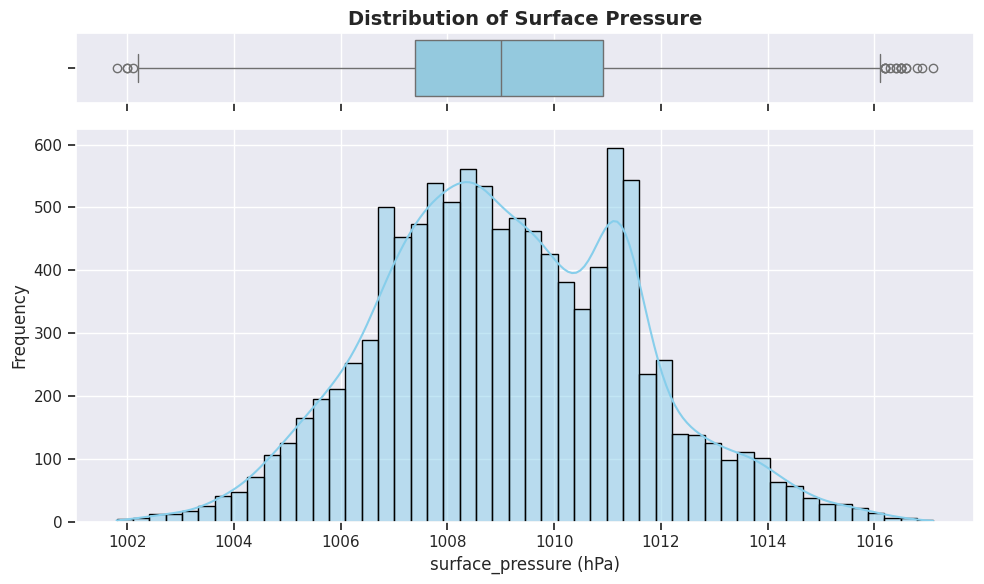

In [10]:
plot_distribution('surface_pressure', 'Distribution of Surface Pressure', unit='(hPa)')

> **Insight - Surface Pressure**:
> - Khái niệm: Là áp lực của cột không khí từ tầng khí quyển đè xuống bề mặt đất, thường được đo bằng đơn vị hPa (hectopascal) hoặc millibar.
> - TP.HCM nằm ở vùng nhiệt đới gần xích đạo nên áp suất bề mặt biến thiên trong một dải rất hẹp (chủ yếu từ 1004 hPa đến 1012 hPa).
> - Áp suất thường đạt đỉnh 2 lần trong ngày (khoảng 9-10h sáng và 9-10h tối).
> - Cần dùng StandardScaler (hoặc MinMaxScaler) để đưa biến này về chung một thang đo (scale)

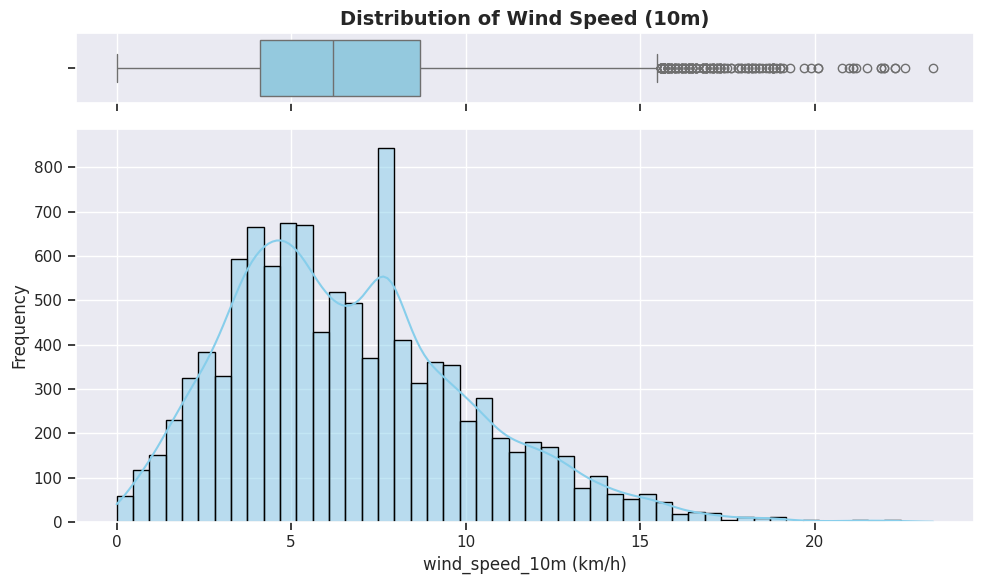

In [11]:
plot_distribution('wind_speed_10m', 'Distribution of Wind Speed (10m)', unit='(km/h)')

> **Insight - Wind Speed**:
> - Tốc độ gió ở TP.HCM thường yếu hoặc trung bình. Đặc điểm đối với PM2.5: tốc độ gió cao làm pha loãng PM2.5, tốc độ gió thấp dẫn đến sự đình trệ và tích tụ cục bộ.
> - Cân nhắc áp dụng Log Transformation (np.log1p) để làm giảm độ lệch.
> - Bắt buộc dùng MinMaxScaler hoặc StandardScaler để đưa dữ liệu về cùng tỷ lệ với các biến khác trước khi nạp vào LSTM/GRU.

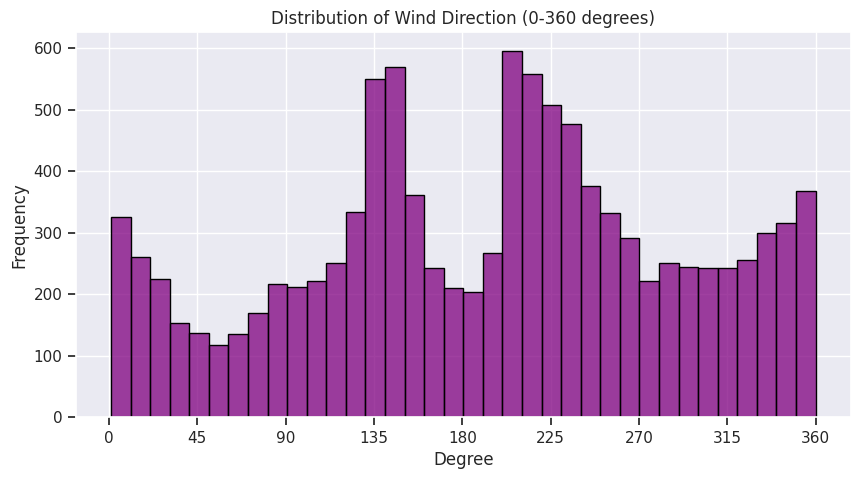

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['wind_direction_10m'], bins=36, color='purple')
plt.title('Distribution of Wind Direction (0-360 degrees)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 361, 45))
plt.show()

> **Insight - Wind Direction**:
> - Thống kê về hướng gió thường thịnh hành ở dạng tuần hoàn. Cần biểu diễn kỹ hơn ở Bivariate và Pollution Rose.
> - Định hướng Preprocessing: Do 0° và 360° cùng là hướng Bắc dễ gây hiểu nhằm cho models ->  không sử dụng biến này trước tiếp mà nên kết hợp với biến wind_speed
> - Wind X (U-wind): $U = \text{wind\_speed\_10m} \times \cos(\text{wind\_direction\_10m} \times \frac{\pi}{180})$
> - Wind Y (V-wind): $V = \text{wind\_speed\_10m} \times \sin(\text{wind\_direction\_10m} \times \frac{\pi}{180})$

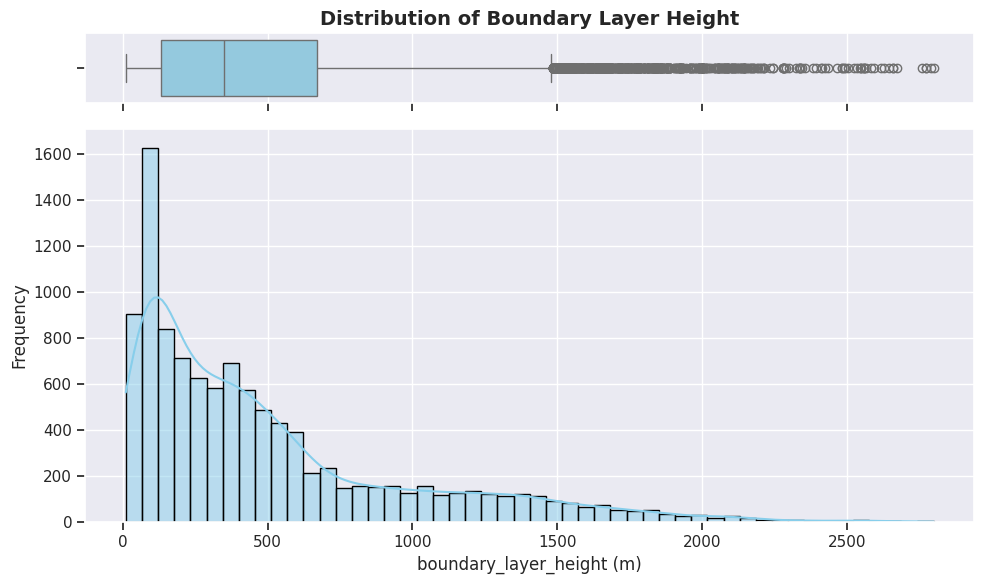

In [13]:
plot_distribution('boundary_layer_height', 'Distribution of Boundary Layer Height', unit='(m)')

> **Insight - Boundary Layer Height (BLH)**:
> - Định nghĩa: Lớp biên hành tinh (Planetary Boundary Layer - PBL) là phần thấp nhất của bầu khí quyển, tiếp xúc trực tiếp với bề mặt Trái Đất. Độ cao của lớp này (Boundary Layer Height - BLH) thay đổi liên tục trong ngày, phụ thuộc vào bức xạ mặt trời và sự truyền nhiệt từ mặt đất lên không khí.
> - Ban ngày (Trưa/Chiều): Mặt đất bị nướng nóng, dòng không khí đối lưu thăng lên mạnh mẽ --> nồng độ PM2.5 giảm loãng ra.
> - Ban đêm/Sáng sớm: Mặt đất lạnh đi, không khí ổn định và chìm xuống --> khiến PM2.5 tăng vọt.
> - Không loại outliers vì dữ liệu này quan trọng -> chỉ Log Transformation và scale (MinMax or Standard)

## 3. Bivariate Analysis
Evaluating relationships between variables and temporal patterns.

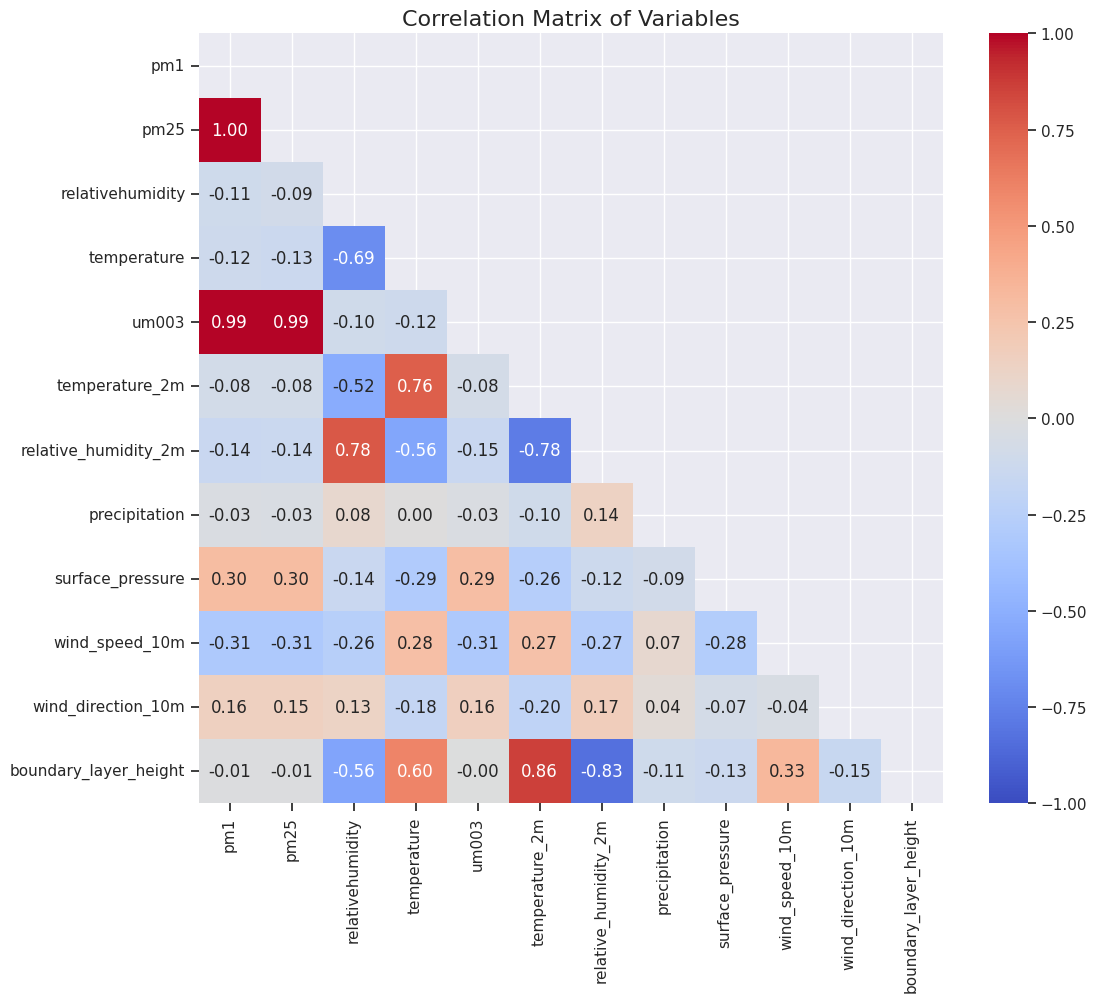

In [14]:
# Correlation Matrix
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.show()

> **Insight - Correlation**:
> - Biến mục tiêu: pm25.
> - Biến loại bỏ (Drop): pm1, um003, temperature (OpenAQ), relativehumidity (OpenAQ), wind_direction_10m (sẽ được thay bằng U/V wind).
> - Biến giữ lại & Cải tiến: boundary_layer_height, temperature_2m, relative_humidity_2m, wind_speed_10m, surface_pressure, và precipitation (chuyển thành các biến phái sinh).

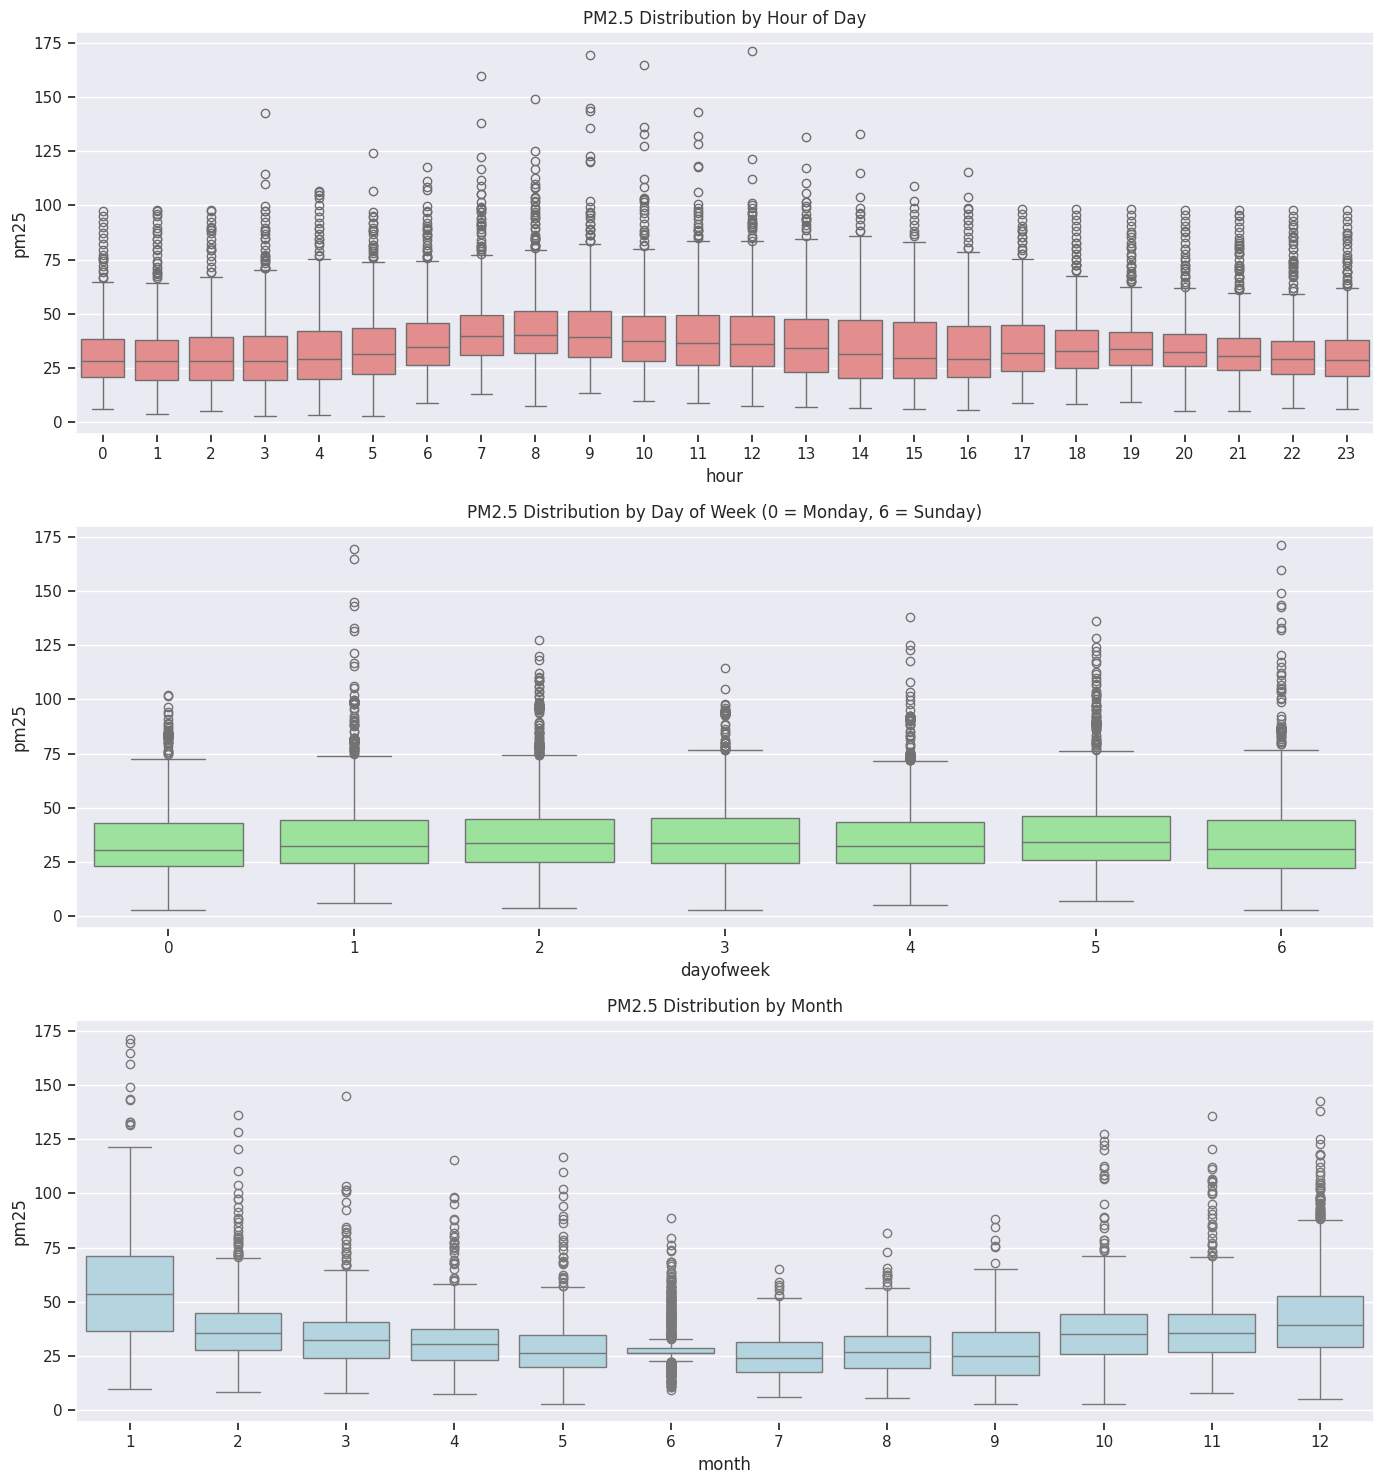

In [15]:
# Extract time features from index
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

sns.boxplot(data=df, x='hour', y='pm25', ax=axes[0], color='lightcoral')
axes[0].set_title('PM2.5 Distribution by Hour of Day')

sns.boxplot(data=df, x='dayofweek', y='pm25', ax=axes[1], color='lightgreen')
axes[1].set_title('PM2.5 Distribution by Day of Week (0 = Monday, 6 = Sunday)')

sns.boxplot(data=df, x='month', y='pm25', ax=axes[2], color='lightblue')
axes[2].set_title('PM2.5 Distribution by Month')

plt.tight_layout()
plt.show()

> **Insight - Temporal Patterns**:
> - **Hour**: Biểu đồ thể hiện rõ hai chu kỳ tăng mạnh của PM2.5 trong một ngày: Đỉnh 1 rơi vào khoảng 7h-9h sáng và Đỉnh 2 rơi vào khoảng 19h-22h tối. Nồng độ PM2.5 chạm đáy (mức thấp nhất) vào khoảng 13h-15h chiều.
> - **Day of Week**: Khó nhìn ra trend vãi.
> - **Month**: Mùa Khô (Tháng 11 - Tháng 4) thiếu hụt lượng mưa --> pm2.5 cao. Mùa Mưa (Tháng 5 - Tháng 10) --> pm2.5 thấp
> - Định hướng: Trích xuất thuộc tính thời gian và tạo biến phân loại (is_rush_hour, is_weekend, is_dry_season)

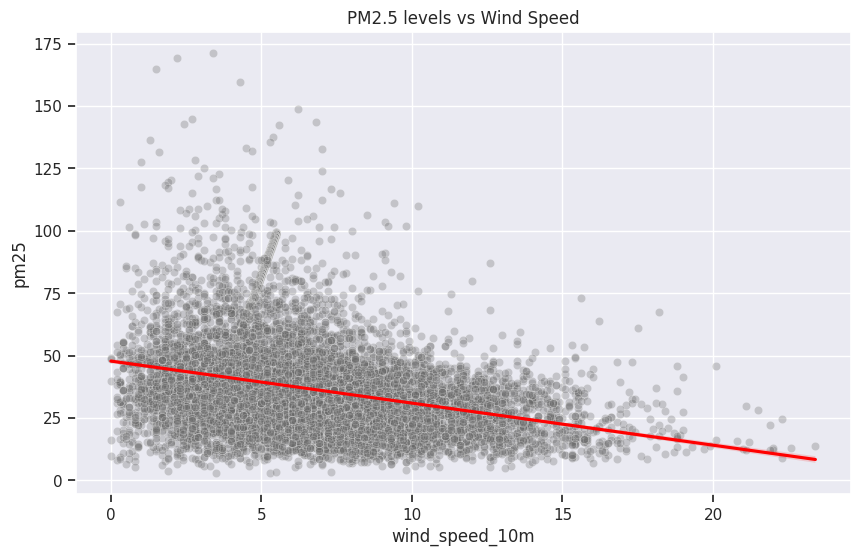

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='wind_speed_10m', y='pm25', alpha=0.3, color='dimgray')
sns.regplot(data=df, x='wind_speed_10m', y='pm25', scatter=False, color='red')
plt.title('PM2.5 levels vs Wind Speed')
plt.show()

> **Insight - PM2.5 vs Wind Speed**:
> - Đường regplot cho thấy xu hướng chênh lệch giảm rõ rệt. Khi tốc độ gió tăng lên, quá trình pha loãng diễn ra mạnh, PM2.5 khó tụ lại một điểm. (Gió càng mạnh, PM2.5 càng giảm.)
> - Tạo biến wind_condition: Stagnant (Đình trệ) nếu wind_speed < 5, Breeze (Gió nhẹ) nếu 5 <= wind_speed < 15, Windy (Có gió mạnh) nếu wind_speed >= 15

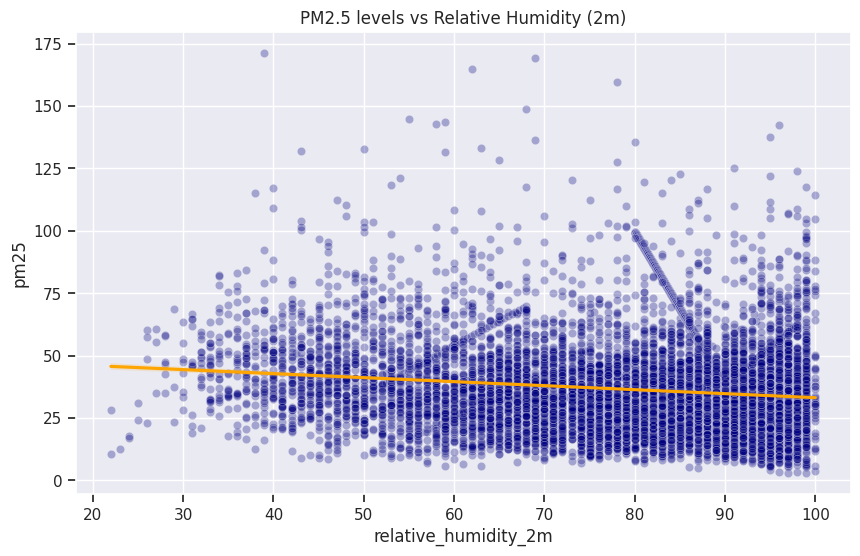

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='relative_humidity_2m', y='pm25', alpha=0.3, color='navy')
sns.regplot(data=df, x='relative_humidity_2m', y='pm25', scatter=False, color='orange')
plt.title('PM2.5 levels vs Relative Humidity (2m)')
plt.show()

> **Insight - PM2.5 vs RH**:
> - Mối quan hệ phức tạp, có thể phi tuyến do độ ẩm quá cao/đạt mức mưa sương sẽ ngưng kết làm rơi PM2.5, nhưng khi ẩm vừa (không mưa) lại làm nổi hoặc tích tụ hạt...
> - Có thể tạo một biến is_washout_condition. Bằng 1 nếu relative_humidity_2m > 95 VÀ precipitation > 0 (ngược lại bằng 0).

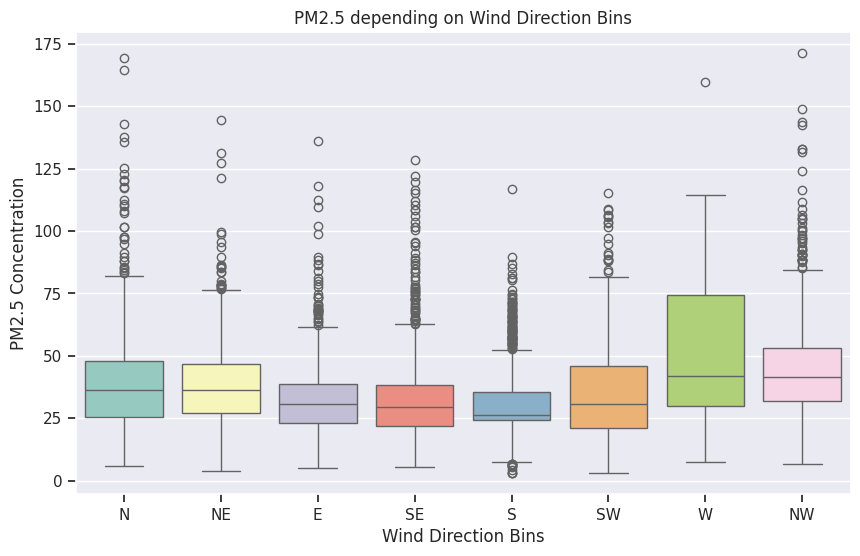

In [18]:
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
df['wind_dir_binned'] = pd.cut(df['wind_direction_10m'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='wind_dir_binned', y='pm25', palette='Set3', order=labels)
plt.title('PM2.5 depending on Wind Direction Bins')
plt.xlabel('Wind Direction Bins')
plt.ylabel('PM2.5 Concentration')
plt.show()

> **Insight - Wind Direction Bins**:
> - Giúp nhận diện được hướng vận chuyển nguồn phát ô nhiễm lân cận (vd: nhà máy nhiệt điện hướng Đông Nam v.v.) sẽ đẩy thẳng tới khu vực này.
> - Nhóm ô nhiễm (Đông Nam, Nam, Đông): PM2.5 rất cao. Thường trùng với gió mùa khô, thổi khói bụi từ các khu công nghiệp (Đồng Nai, Bình Dương) và cảng Cát Lái vào trung tâm thành phố.
> - Nhóm sạch (Tây, Tây Bắc, Bắc): PM2.5 thấp. Tương ứng với Gió mùa Tây Nam (mùa mưa), mang theo mưa rào giúp làm sạch không khí.
> - Với XGBoost/LightGBM: Dùng One-Hot Encoding trực tiếp trên các bin (VD: is_wind_SE, is_wind_W).
> - Với LSTM/SARIMAX: Mã hóa lượng giác thành 2 vector liên tục là U-wind và V-wind để mô hình toán học dễ học hơn.

## 4. Multivariate Analysis & Time-Series Component

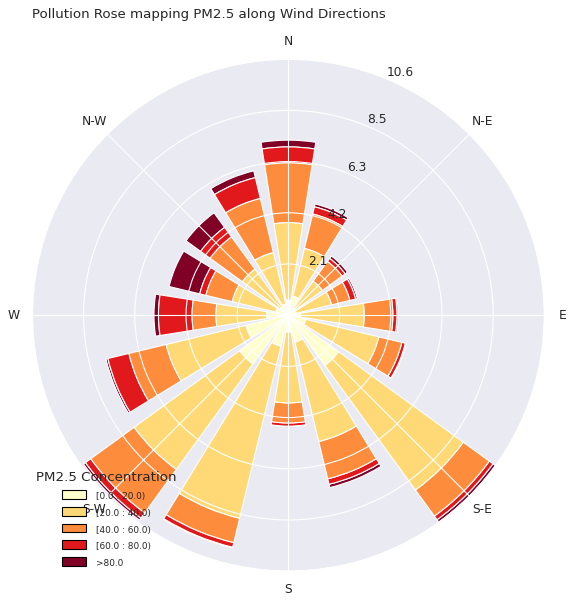

In [19]:
# Note: Remove nulls for Pollution Rose
df_wind = df.dropna(subset=['wind_direction_10m', 'wind_speed_10m', 'pm25'])

# Create a Pollution Rose 
ax = WindroseAxes.from_ax()
ax.bar(df_wind['wind_direction_10m'], df_wind['pm25'], bins=np.arange(0, 100, 20), normed=True, opening=0.8, edgecolor='white', cmap=plt.cm.YlOrRd)
ax.set_legend(title='PM2.5 Concentration')
ax.set_title('Pollution Rose mapping PM2.5 along Wind Directions', loc='left', pad=15)
plt.show()

> **Insight - Pollution Rose**:
> - Biểu đồ này phối hợp cả 3 biến: PM2.5, Hướng Gió và Tần suất, cung cấp sự quan sát trực quan nhất những "cánh cung" (phương tiện/luồng gió) nào mang nhiều bụi tới TP.HCM nhất.
> - Nhóm ô nhiễm (Đông Nam, Nam, Đông): PM2.5 rất cao. Thường trùng với gió mùa khô, thổi khói bụi từ các khu công nghiệp (Đồng Nai, Bình Dương) và cảng Cát Lái vào trung tâm thành phố.
> - Nhóm sạch (Tây, Tây Bắc, Bắc): PM2.5 thấp. Tương ứng với Gió mùa Tây Nam (mùa mưa), mang theo mưa rào giúp làm sạch không khí.

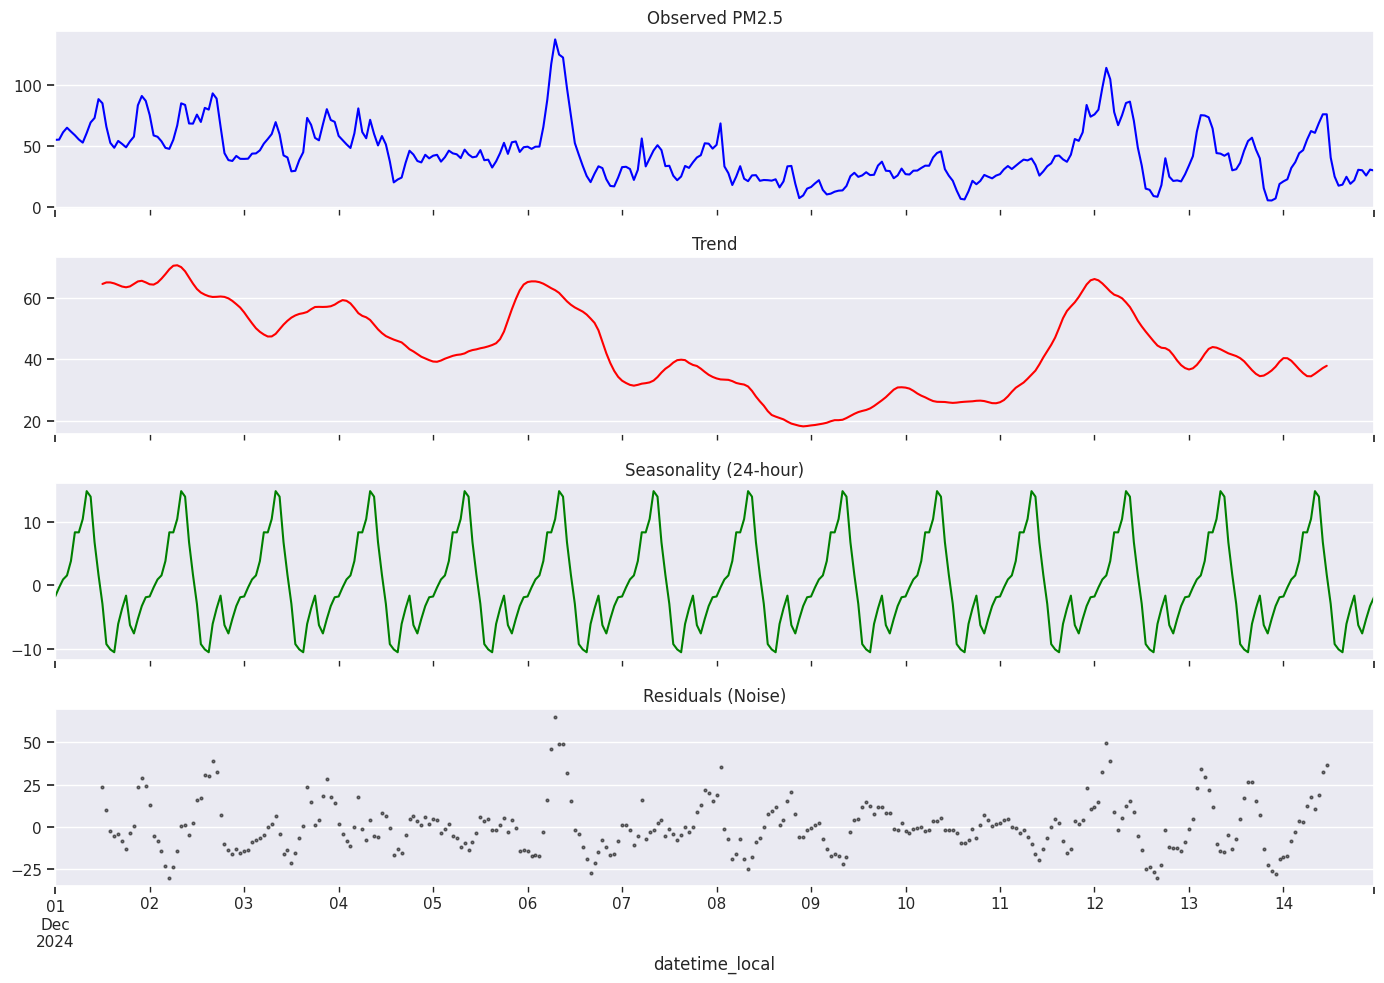

In [20]:
# Time-series Decompose require continuous dates, filling NA with interpolation
df_res = df['pm25'].resample('h').mean().interpolate()

# Limit to 2 weeks for visualization
df_sample = df_res.loc['2024-12-01':'2024-12-14'] 
if not df_sample.empty:
    decomposition = seasonal_decompose(df_sample, model='additive', period=24) # 24 hours daily pattern
    
    # Custom plotting to make it look nice
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    decomposition.observed.plot(ax=axes[0], color='blue', title='Observed PM2.5')
    decomposition.trend.plot(ax=axes[1], color='red', title='Trend')
    decomposition.seasonal.plot(ax=axes[2], color='green', title='Seasonality (24-hour)')
    decomposition.resid.plot(ax=axes[3], color='black', alpha=0.5, title='Residuals (Noise)', style='o', markersize=2)
    plt.tight_layout()
    plt.show()
else:
    print('Sample duration does not match data availability.')

> **Insight - TS Decompose**:
> - Trend (Xu hướng): Không tăng/giảm tuyến tính mà dao động lượn sóng theo Chu kỳ Mùa (Mùa khô cao - Mùa mưa thấp).
> - Seasonal (Chu kỳ): Tính tuần hoàn cực kỳ ổn định, đại diện cho Chu kỳ Ngày - Đêm (Kẹt xe sáng/chiều, nghịch nhiệt ban đêm).
> - Residual (Phần dư): Rất lớn và biến động mạnh. Chứng tỏ yếu tố thời gian thuần túy không đủ để dự báo PM2.5.
> - Mô hình thống kê cơ bản (ARIMA, SARIMA) sẽ không hoạt động tốt và bắt buộc sử dụng các mô hình có biến ngoại sinh (ARIMAX, SARIMAX) hoặc Machine Learning (XGBoost, LSTM) kết hợp với dữ liệu thời tiết để bắt được các đỉnh ô nhiễm đột biến.

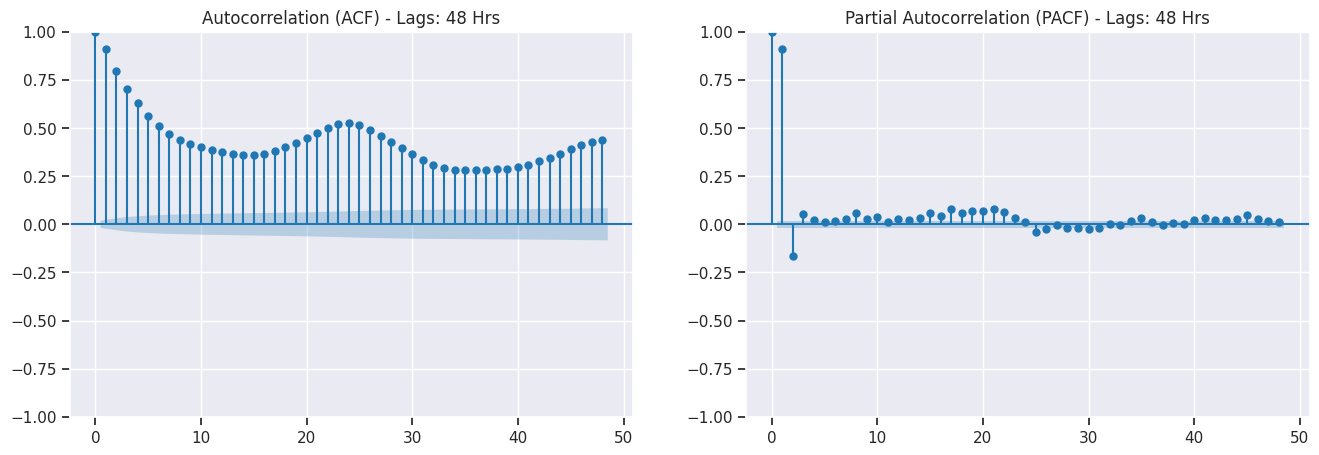

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_res.dropna(), ax=axes[0], lags=48)
axes[0].set_title('Autocorrelation (ACF) - Lags: 48 Hrs')

plot_pacf(df_res.dropna(), ax=axes[1], lags=48)
axes[1].set_title('Partial Autocorrelation (PACF) - Lags: 48 Hrs')
plt.show()

> **Insight - ACF/PACF**:
> - ACF (Hàm tự tương quan): Suy giảm rất chậm và có gợn sóng ở chu kỳ 24, 48. Chứng tỏ chuỗi PM2.5 không dừng (non-stationary) và có tính mùa vụ theo ngày (24h cycle). Bắt buộc phải lấy sai phân ($d=1$) nếu dùng họ mô hình ARIMA.
> - PACF (Hàm tự tương quan riêng phần): Cắt đứt cực mạnh sau Lag 1 và Lag 2, có gai nhỏ ở Lag 24. Chứng tỏ nồng độ bụi hiện tại chỉ phụ thuộc trực tiếp vào 1-2 giờ liền trước và cùng giờ ngày hôm qua.
> - Hành động (Feature Engineering): Cung cấp cơ sở toán học vững chắc để chốt danh sách biến trễ (Lag features): chỉ cần tạo PM2.5(t-1), PM2.5(t-2) và PM2.5(t-24) làm đầu vào cho Machine Learning/Deep Learning, giúp giảm chiều dữ liệu dư thừa.

## 5. Class Balance: AQI Evaluation (Chuẩn Việt Nam - VN AQI)
Tính phân lớp và chênh lệch lớp AQI (thông qua nồng độ PM2.5 theo chuẩn VN) để cung cấp insight cho mô hình nếu chuyển thành bài toán Classification, hoặc đánh giá rủi ro.
*(Dựa theo Quyết định 1459/QĐ-TCMT)*

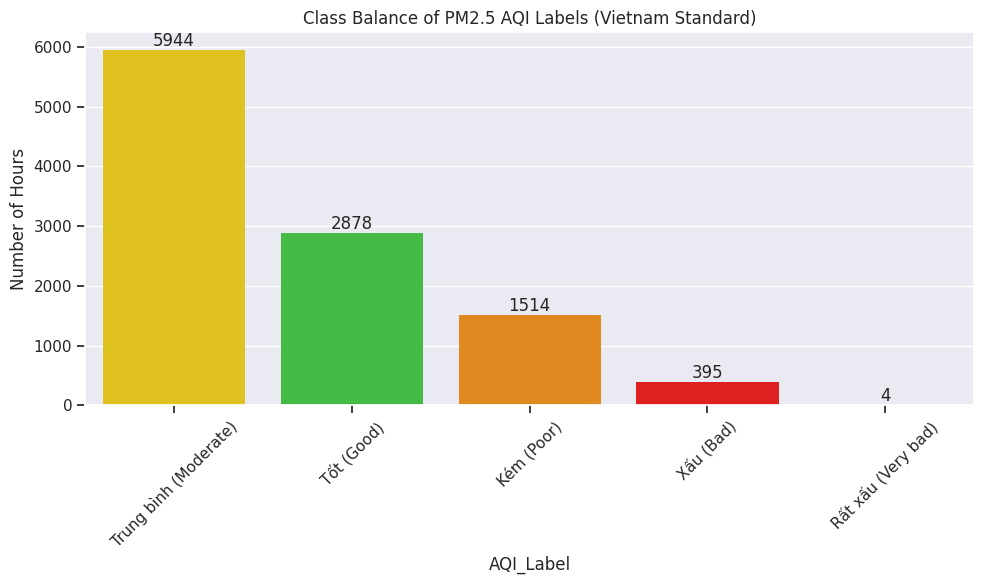

In [22]:
def calculate_aqi_vn(pm):
    if pd.isna(pm): return None
    if pm <= 25.0: return 'Tốt (Good)'
    elif pm <= 50.0: return 'Trung bình (Moderate)'
    elif pm <= 80.0: return 'Kém (Poor)'
    elif pm <= 150.0: return 'Xấu (Bad)'
    elif pm <= 250.0: return 'Rất xấu (Very bad)'
    else: return 'Nguy hại (Hazardous)'

df['AQI_Label'] = df['pm25'].apply(calculate_aqi_vn)

aqi_counts = df['AQI_Label'].value_counts()

plt.figure(figsize=(10, 6))
# Define colors typically used in VN AQI maps
colors_map = {'Tốt (Good)': 'limegreen', 'Trung bình (Moderate)': 'gold', 'Kém (Poor)': 'darkorange',
              'Xấu (Bad)': 'red', 'Rất xấu (Very bad)': 'purple', 'Nguy hại (Hazardous)': 'saddlebrown'}
aqi_colors = [colors_map.get(lbl, 'grey') for lbl in aqi_counts.index]

sns.barplot(x=aqi_counts.index, y=aqi_counts.values, palette=aqi_colors)
plt.title('Class Balance of PM2.5 AQI Labels (Vietnam Standard)')
plt.ylabel('Number of Hours')
plt.xticks(rotation=45)
for i, v in enumerate(aqi_counts.values):
    plt.text(i, v + 2, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

> **Insight - Class Balance (VN Standard)**:
> - So với chuẩn US EPA, chuẩn VN nới lỏng hơn ở các ngưỡng ban đầu, do đó số lượng giờ được đánh giá là 'Tốt' và 'Trung bình' sẽ nhiều hơn.
> - Tuy nhiên, sự mất cân bằng dữ liệu (Imbalanced Data) vẫn rất hiện hữu. Các nhãn 'Xấu' (Bad) trở lên chiếm cực kỳ ít.
> - Định hướng: Khi xây dựng mô hình cảnh báo mức độ ô nhiễm (Classification), bắt buộc phải dùng các kỹ thuật xử lý mất cân bằng như SMOTE, Class Weights, hoặc Focal Loss để mô hình không bị lệch.

# KẾT LUẬN
### 1. Tổng quan về Data Insights (General Insights)

Quá trình phân tích đã làm sáng tỏ một số đặc trưng vật lý và thống kê vô cùng quan trọng mà toàn team cần nắm vững:

* **Tính phân phối lệch (Extreme Right-skewness) và Ngoại lệ (Outliers):** Đa phần các biến lõi như nồng độ bụi (`pm25`), `boundary_layer_height`, lượng mưa (`precipitation`) đều bị lệch phải nghiêm trọng. Các điểm outliers thực chất mang tín hiệu môi trường rất mạnh (như các đợt nghịch nhiệt ban đêm hoặc mưa rào) chứ không phải lỗi sensor. 
* **Vấn đề Đa cộng tuyến (Multicollinearity) & Data Leakage:** Dữ liệu có sự trùng lặp lớn. Các biến hạt nhỏ (`pm1`, `um003`) tương quan gần như tuyệt đối (r > 0.95) với `pm25`, mang rủi ro rò rỉ dữ liệu cực cao. Bên cạnh đó, dữ liệu vi khí hậu từ trạm đo (OpenAQ) trùng lặp với dữ liệu vĩ mô (OpenMeteo) nhưng lại chứa nhiều nhiễu hơn.
* **Hiệu ứng phi tuyến tính (Non-linear Effects):** Mối quan hệ giữa thời tiết và bụi mịn không đi theo đường thẳng. Ví dụ: Gió chỉ thực sự làm sạch không khí khi vượt qua một ngưỡng (threshold) nhất định; độ ẩm cao làm hạt bụi phình to (tăng PM2.5) nhưng độ ẩm bão hòa sinh ra mưa lại làm "rửa trôi" bụi (giảm PM2.5 đột ngột).
* **Chu kỳ thời gian rõ rệt (Temporal Seasonality & Diurnal Cycle):** Dữ liệu thể hiện tính chu kỳ theo ngày (đỉnh kẹt xe sáng/tối) và theo mùa vụ (mùa khô ô nhiễm nặng, mùa mưa không khí sạch). Khảo sát ACF/PACF cho thấy tính tự tương quan mạnh nhất nằm ở Lag 1, Lag 2 và Lag 24.
* **Mất cân bằng nghiêm trọng (Extreme Class Imbalance):** Khi xét theo nhãn AQI chuẩn Việt Nam, >95% dữ liệu tập trung ở mức Tốt/Trung bình. Các nhãn Xấu/Kém rất hiếm, đây là một thách thức lớn (challenge) nếu team định xây dựng Classification model.

---

### 2. Chiến lược Preprocessing & Feature Engineering (Action Plan)

Dựa trên các insights trên, tôi đã hệ thống hóa phương hướng xử lý cho từng biến thành bảng dưới đây để các bạn phụ trách phần Code Preprocessing dễ dàng follow và implement:

| Nhóm Data | Tên Biến (Feature) | Insight Thống Kê / Vật Lý | Action / Kỹ thuật Preprocessing |
| :--- | :--- | :--- | :--- |
| **Mục tiêu** | `pm25` | Lệch phải, Outliers mang tín hiệu mạnh. | **Giữ Outliers.** Dùng Log Transformation (vd: `np.log1p`) để ổn định phương sai cho LSTM/SARIMA. |
| **Bụi khác** | `pm1`, `um003` | Rủi ro Data Leakage, Đa cộng tuyến (VIF cao). | **DROP hoàn toàn** khỏi tập training để tránh mô hình học "gian lận". |
| **Thời tiết (Nhiễu)** | `temperature`, `relativehumidity` (từ OpenAQ) | Đa cộng tuyến với dữ liệu OpenMeteo, độ tin cậy của sensor cục bộ kém hơn. | **DROP hoàn toàn.** Ưu tiên sử dụng dữ liệu từ OpenMeteo để đảm bảo tính ổn định (robustness). |
| **Thời tiết (Vĩ mô)** | `temperature_2m`, `relative_humidity_2m` | Có tác động phi tuyến tính đến PM2.5. | Scale bằng `MinMaxScaler` hoặc `StandardScaler`. Tạo thêm biến tương tác kết hợp với Mưa. |
| **Mưa** | `precipitation` | Phân phối Zero-inflated (Chủ yếu là số 0). Rửa trôi bụi (Washout effect). | Không Log. **Feature Creation:** Tạo flag `is_raining` (0/1) và `hours_since_last_rain` cho Tree-based models. |
| **Áp suất** | `surface_pressure` | Ảnh hưởng tới lưu thông không khí. Dải giá trị hẹp. | Scale bằng `StandardScaler`. **Feature Creation:** Tính độ lệch áp suất $\Delta P$ (vd: $P_t - P_{t-3}$). |
| **Lớp biên** | `boundary_layer_height` | Lệch phải cực độ, nghịch đảo với nồng độ bụi. | **Log Transformation (Bắt buộc).** Áp dụng Scaling. |
| **Gió** | `wind_speed_10m`, `wind_direction_10m` | Gió mạnh thổi bay bụi. Hướng gió mang tính chu kỳ (Cyclical nature). | **DROP `wind_direction_10m`.** Phân rã thành 2 vector liên tục: **U-wind** và **V-wind** (dùng $\sin$, $\cos$). |
| **Thời gian** | `datetime` (Index) | Chu kỳ ngày-đêm và mùa vụ rõ rệt. | **Trích xuất:** `hour`, `day_of_week`, `month`. Áp dụng **Cyclical Encoding** cho `hour` và `month`. |
| **Lag / History** | *N/A (Tạo mới)* | ACF/PACF chứng minh tính phụ thuộc ngắn hạn và chu kỳ ngày. | **Tạo Lag Features:** `PM2.5(t-1)`, `PM2.5(t-2)` và `PM2.5(t-24)`. Thêm biến Rolling Window (Mean 6h, 12h). |

---

### 3. Đề xuất của Team Lead cho chặng tiếp theo

Dựa vào bảng kế hoạch trên, yêu cầu các bạn trong team tiến hành viết script xử lý theo đúng các module đã chia. Đặc biệt chú ý:
* **Đối với các bạn làm Tree-based Models (XGBoost, LightGBM):** Thuật toán tự xử lý tốt phân phối lệch, hãy tập trung vào việc tạo ra càng nhiều Categorical flags (ví dụ: `is_weekend`, `is_dry_season`, `is_temperature_inversion`) càng tốt để cây quyết định rẽ nhánh tối ưu.
* **Đối với các bạn làm Deep Learning (LSTM, GRU):** Bắt buộc phải cực kỳ cẩn thận ở khâu Transformation và Scaling. Phải đưa tất cả các biến về chung một dải giá trị (thường là [0, 1] hoặc [-1, 1]) nếu không hiện tượng Exploding Gradients sẽ phá hỏng toàn bộ quá trình training.

---

### 📌 Takeaway Notes (Dành cho việc viết Report)
* **Bỏ bớt nhiễu:** Loại bỏ ngay các biến gây đa cộng tuyến (`pm1`, `um003`, sensor data từ OpenAQ).
* **Toán học hóa Tự nhiên:** Chuyển đổi các biến chu kỳ (Thời gian, Hướng gió) thành các thành phần $\sin$ / $\cos$ (Cyclical Encoding).
* **Khai thác tính tự tương quan:** Bộ 3 biến Lag bắt buộc phải có là `t-1`, `t-2` và `t-24` (chứng minh bằng PACF).
* **Xử lý Outliers:** Giữ nguyên các giá trị ngoại lệ vì đây là hiện tượng cực đoan của môi trường. Dùng Log Transformation để bình ổn dữ liệu.